<a href="https://colab.research.google.com/github/VaibhavK010/Weater_Classification_using_SVM/blob/main/Assignement_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt

In [2]:
import requests

latitude = 31.1048
longitude = 77.1734

url = (
    f"https://archive-api.open-meteo.com/v1/archive?"
    f"latitude={latitude}"
    f"&longitude={longitude}"
    f"&start_date=2026-01-01"
    f"&end_date=2026-07-28"
    f"&hourly=temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m"
)

response = requests.get(url)
data = response.json()

In [3]:
print(data.keys())

dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly'])


In [4]:
print(data["hourly"].keys())

dict_keys(['time', 'temperature_2m', 'relative_humidity_2m', 'surface_pressure', 'wind_speed_10m'])


In [5]:
df = pd.DataFrame({
    "Time": data["hourly"]["time"],
    "Temperature": data["hourly"]["temperature_2m"],
    "Humidity": data["hourly"]["relative_humidity_2m"],
    "Pressure": data["hourly"]["surface_pressure"],
    "WindSpeed": data["hourly"]["wind_speed_10m"]
})

In [6]:
df.head()

,Time,Temperature,Humidity,Pressure,WindSpeed
0,2026-01-01T00:00,0.9,73,775.7,3.0
1,2026-01-01T01:00,1.7,64,776.6,4.8
2,2026-01-01T02:00,1.7,62,777.2,5.4
3,2026-01-01T03:00,2.8,60,778.5,5.9
4,2026-01-01T04:00,3.9,58,780.4,5.5


In [7]:
df["Weather_Class"] = df["Temperature"].apply(
    lambda x: "Warm" if x >= 25 else "Cool"
)

In [8]:
df.head()

,Time,Temperature,Humidity,Pressure,WindSpeed,Weather_Class
0,2026-01-01T00:00,0.9,73,775.7,3.0,Cool
1,2026-01-01T01:00,1.7,64,776.6,4.8,Cool
2,2026-01-01T02:00,1.7,62,777.2,5.4,Cool
3,2026-01-01T03:00,2.8,60,778.5,5.9,Cool
4,2026-01-01T04:00,3.9,58,780.4,5.5,Cool


In [9]:
X = df[["Temperature", "Humidity", "Pressure", "WindSpeed"]]

In [10]:
y = df["Weather_Class"]

In [11]:
df.isnull().sum()

,0
Time,0
Temperature,0
Humidity,0
Pressure,0
WindSpeed,0
Weather_Class,0


In [12]:
df = df.drop("Time", axis=1)

In [13]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [15]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [16]:
model = SVC(kernel="rbf")

In [17]:
model.fit(X_train, y_train)

SVC()

In [18]:
y_pred = model.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9920318725099602
Precision: 1.0
Recall   : 0.2727272727272727
F1 Score : 0.42857142857142855


In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=encoder.classes_))

              precision    recall  f1-score   support

        Cool       0.99      1.00      1.00       993
        Warm       1.00      0.27      0.43        11

    accuracy                           0.99      1004
   macro avg       1.00      0.64      0.71      1004
weighted avg       0.99      0.99      0.99      1004



In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[993   0]
 [  8   3]]


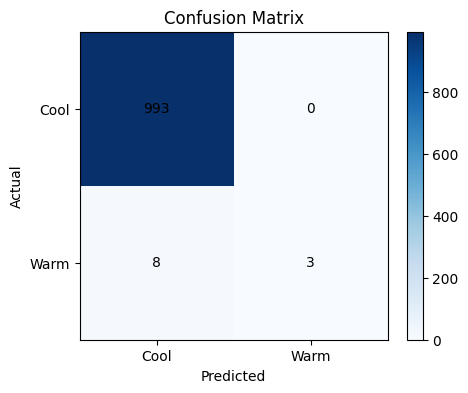

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], encoder.classes_)
plt.yticks([0,1], encoder.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.show()